In [67]:
import sys
from pathlib import Path
sys.path.append(str(Path("..") / "code"))

from equilibrium_solver import solve_equilibrium
from simulation import run_simulation

import pandas as pd
import matplotlib.pyplot as plt

In [68]:
values, attack_probs, sucker_probs = solve_equilibrium(8)

df = pd.DataFrame({
    "PP": list(range(len(values))),
    "Win Probability": values,
    "Attack Probability": attack_probs,
    "Sucker Punch Probability": sucker_probs
})

df

,PP,Win Probability,Attack Probability,Sucker Punch Probability
0,0,1.000000,1.000000,0.000000
1,1,0.500000,0.500000,0.500000
2,2,0.333333,0.333333,0.666667
3,3,0.250000,0.250000,0.750000
4,4,0.200000,0.200000,0.800000
5,5,0.166667,0.166667,0.833333
6,6,0.142857,0.142857,0.857143
7,7,0.125000,0.125000,0.875000
8,8,0.111111,0.111111,0.888889


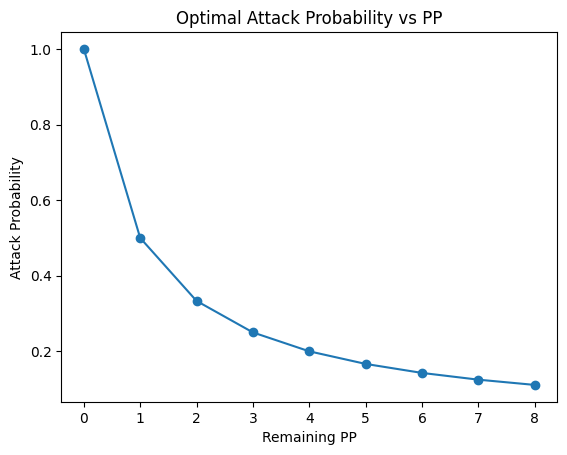

In [69]:
plt.plot(df["PP"], df["Attack Probability"], marker="o")
plt.xlabel("Remaining PP")
plt.ylabel("Attack Probability")
plt.title("Optimal Attack Probability vs PP")
plt.savefig("../figures/pp_vs_attack_probability.png", dpi=300, bbox_inches="tight")
plt.show()

In [70]:
sim_win_rate, theory_win_rate, turn_counts = simulation.run_simulation(8, 1000000)

print("Simulated win rate:", sim_win_rate)
print("Theoretical win rate:", theory_win_rate)

print("\nWin turn distribution:")
for turn in sorted(turn_counts):
    print("Turn", turn, ":", turn_counts[turn])

Simulated win rate: 0.110935
Theoretical win rate: 0.11111111111111113

Win turn distribution:
Turn 1 : 12207
Turn 2 : 12484
Turn 3 : 12333
Turn 4 : 12189
Turn 5 : 12252
Turn 6 : 12406
Turn 7 : 12313
Turn 8 : 12300
Turn 9 : 12451


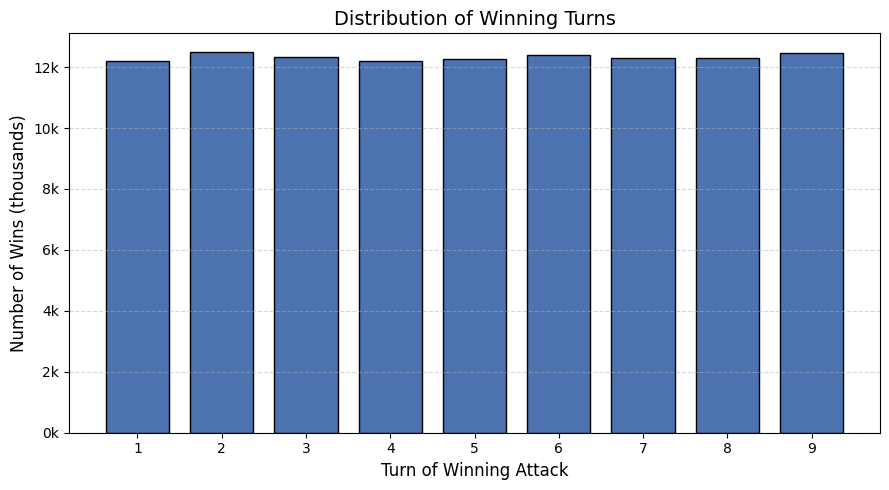

In [71]:
from matplotlib.ticker import FuncFormatter
turns = sorted(turn_counts.keys())
wins = [turn_counts[t] for t in turns]
plt.figure(figsize=(9,5))
plt.bar(turns, wins, color="#4C72B0", edgecolor="black", width=0.75)
plt.xlabel("Turn of Winning Attack", fontsize=12)
plt.ylabel("Number of Wins (thousands)", fontsize=12)
plt.title("Distribution of Winning Turns", fontsize=14)
def thousands(x, pos):
    return f'{int(x/1000)}k'
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands))
plt.xticks(turns)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("../figures/winning_turn_distribution_clean.png", dpi=300)
plt.show()

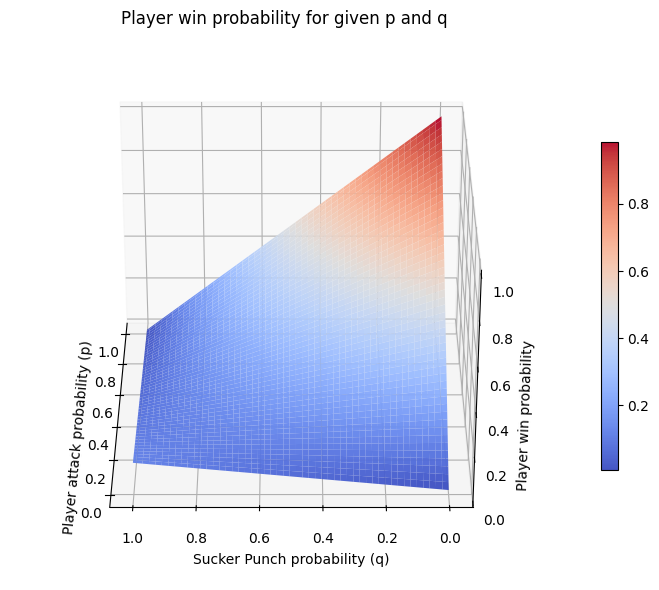

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# choose V_{k-1} (example: if k=8 then V7 = 1/8)
V_prev = 1/8

# create grid for p and q
p = np.linspace(0,1,100)
q = np.linspace(0,1,100)
P, Q = np.meshgrid(p, q)

# payoff function
Z = P*(1-Q) + (1-P)*Q*V_prev

# create plot
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    P, Q, Z,
    cmap='coolwarm',
    edgecolor='none',
    alpha=0.95
)

# labels
ax.set_xlabel("Player attack probability (p)")
ax.set_ylabel("Sucker Punch probability (q)")
ax.set_zlabel("Player win probability")

ax.set_title("Player win probability for given p and q")

# nicer viewing angle
ax.view_init(elev=30, azim=-180)

# colorbar
fig.colorbar(surf, shrink=0.6)

plt.tight_layout()
plt.savefig("../figures/payoff_surface.png", dpi=300)
plt.show()